# Tugas - Klasifikasi dengan Artificial Neural Network (ANN)

| Nama | NRP |
|------|-----|
| Benedictus Ryu Gunawan | 5054251001 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model ANN (Multi-Layer Perceptron) Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja ANN secara praktik, khususnya:
1. Perbedaan hasil antar fungsi aktivasi (ReLU, Tanh, Logistic/Sigmoid)
2. Pengaruh ukuran arsitektur (`hidden_layer_sizes`) dan jumlah iterasi terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model, termasuk feature scaling.
3. Eksperimen Model
   - Bangun model ANN dengan arsitektur dasar.
   - Lakukan eksperimen fungsi aktivasi dan regularisasi arsitektur.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif

In [2]:
TARGET = "diagnosis"
df = pd.read_csv("data/ann_data.csv")
df = df.drop(columns=["id", "Unnamed: 32"])

print("Jumlah baris dan kolom:", df.shape)
print("Tipe data:")
display(df.dtypes)
print("Jumlah missing value:")
display(df.isnull().sum())

Jumlah baris dan kolom: (569, 31)
Tipe data:


diagnosis                      str
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst            float64
concave points_worst

Jumlah missing value:


diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

Distribusi kelas target:


diagnosis
B    357
M    212
Name: count, dtype: int64

Proporsi kelas:


diagnosis
B    0.6274
M    0.3726
Name: proportion, dtype: float64

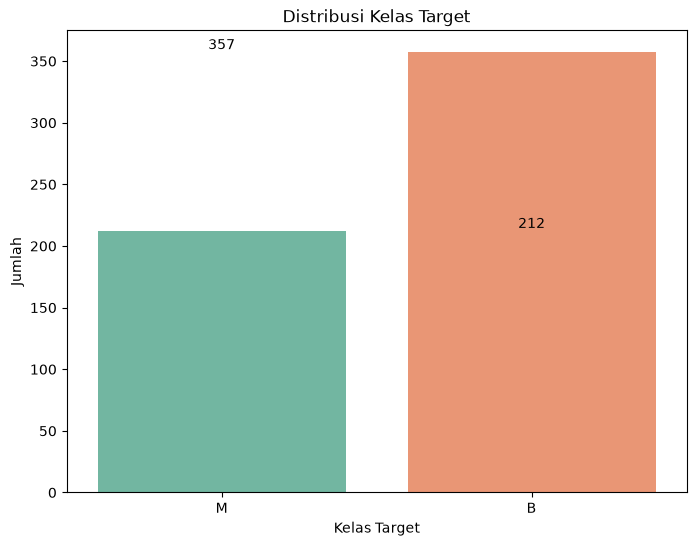

In [3]:
print("Distribusi kelas target:")
display(df[TARGET].value_counts())
print("Proporsi kelas:")
display(df[TARGET].value_counts(normalize=True).round(4))

plt.figure(figsize=(8, 6))
sns.countplot(x=TARGET, hue=TARGET, data=df, palette="Set2", legend=False)
plt.title("Distribusi Kelas Target")
for index, value in enumerate(df[TARGET].value_counts()):
    plt.text(index, value, str(value), ha="center", va="bottom")
plt.xlabel("Kelas Target")
plt.ylabel("Jumlah")
plt.show()

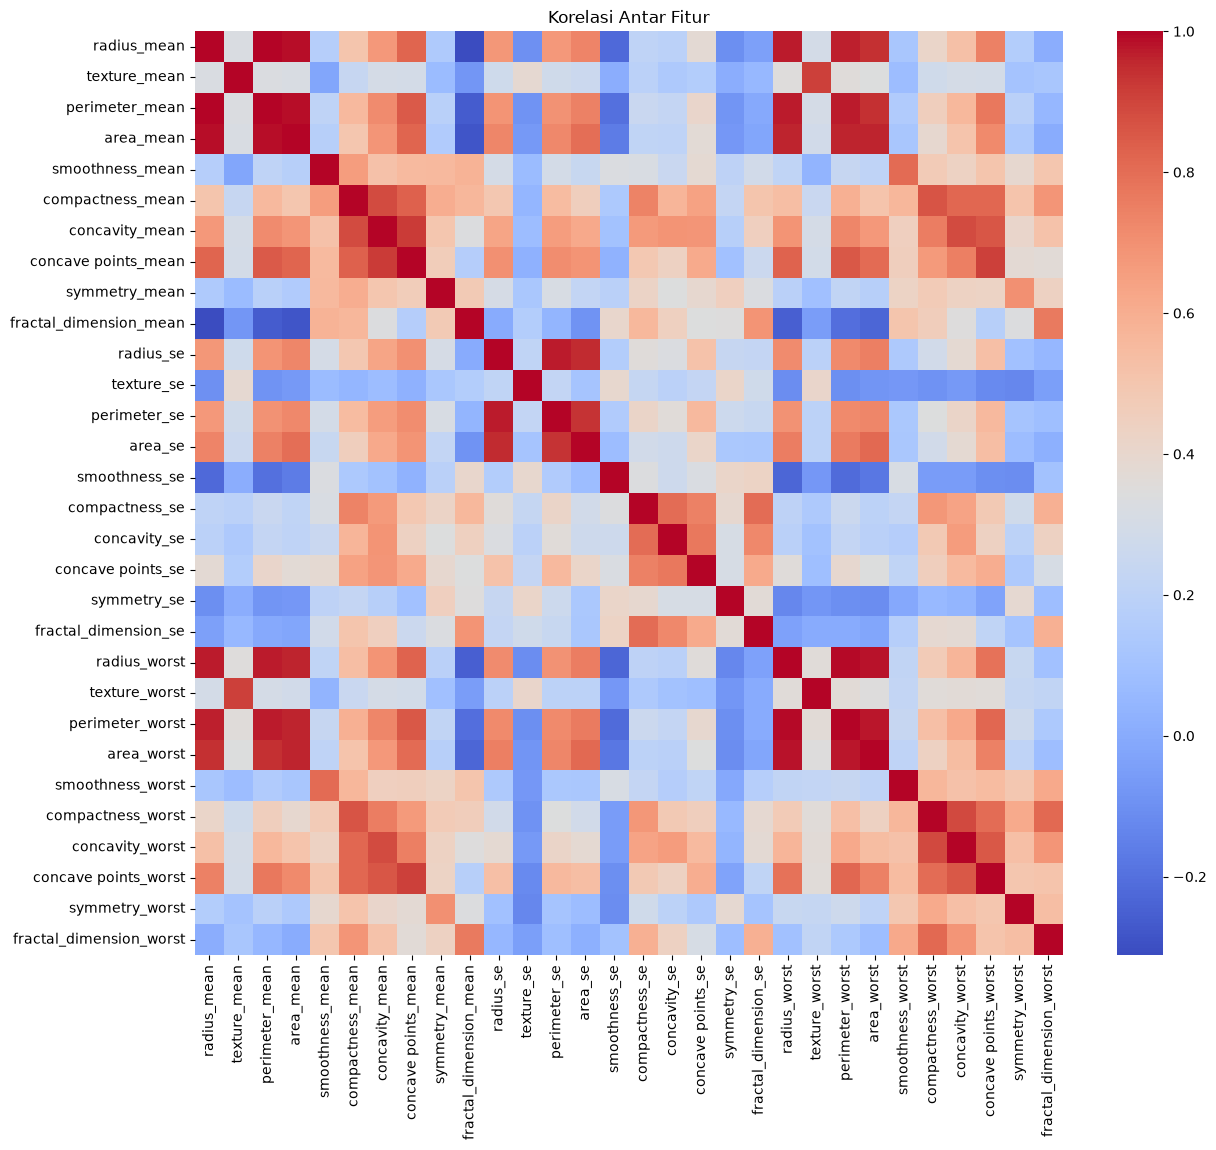

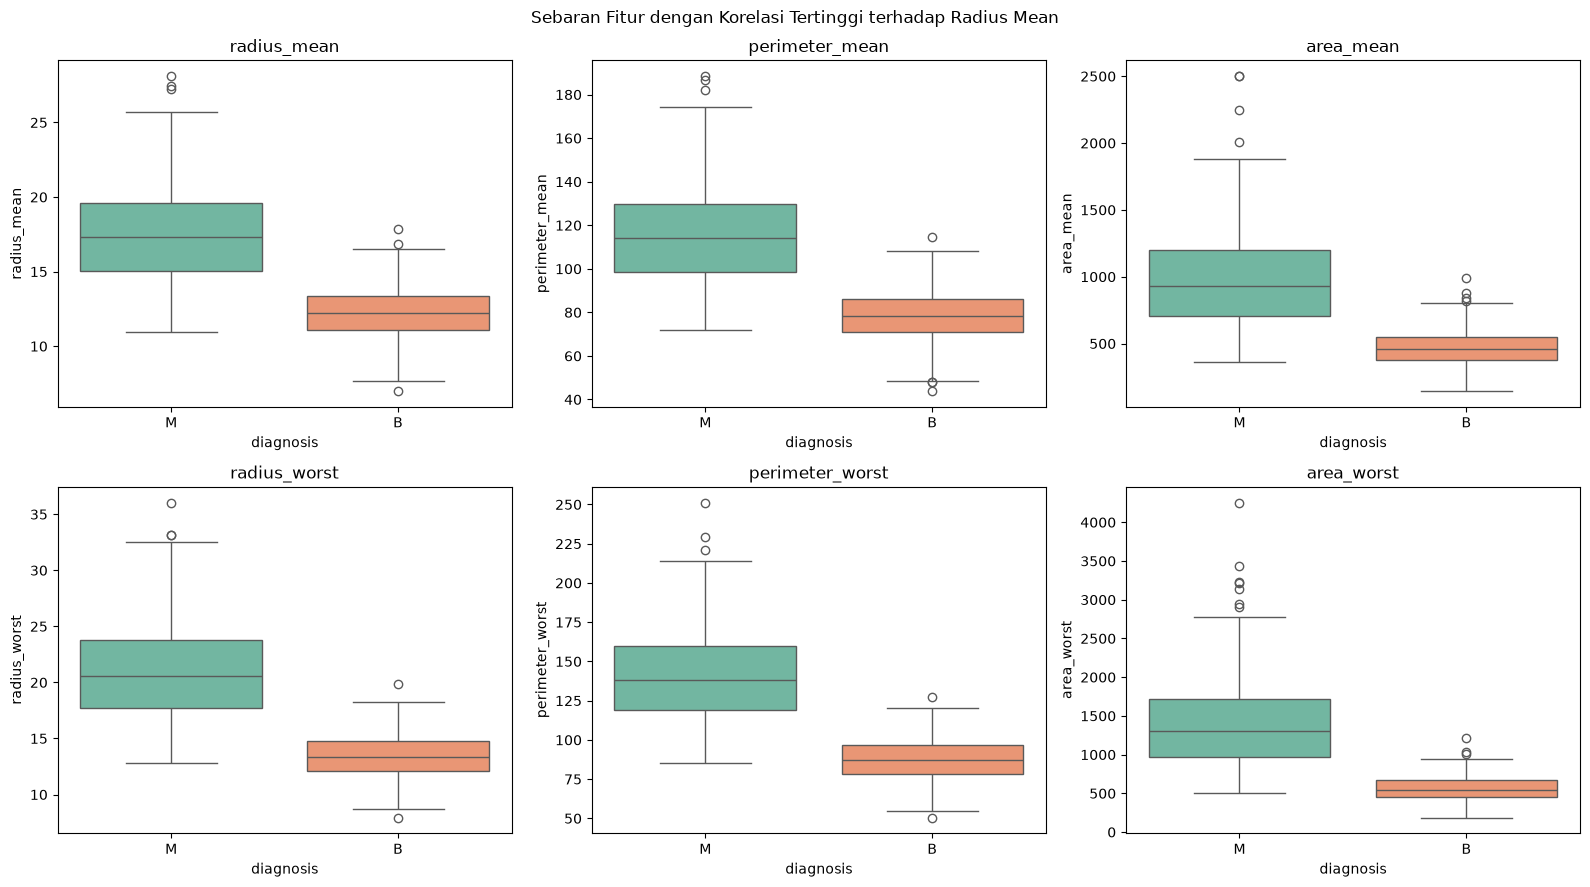

In [4]:
numeric_cols = df.drop(columns=[TARGET])
corr_matrix = numeric_cols.corr()
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Korelasi Antar Fitur")
plt.show()

top_corr_features = corr_matrix["radius_mean"].abs().sort_values(ascending=False).head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, feature in zip(axes.flatten(), top_corr_features):
    sns.boxplot(x=TARGET, hue=TARGET, y=feature, data=df, ax=ax, palette="Set2", legend=False)
    ax.set_title(feature)
plt.suptitle("Sebaran Fitur dengan Korelasi Tertinggi terhadap Radius Mean")
plt.tight_layout()
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

Eksplorasi tambahan: sebaran kelas target pada beberapa fitur utama


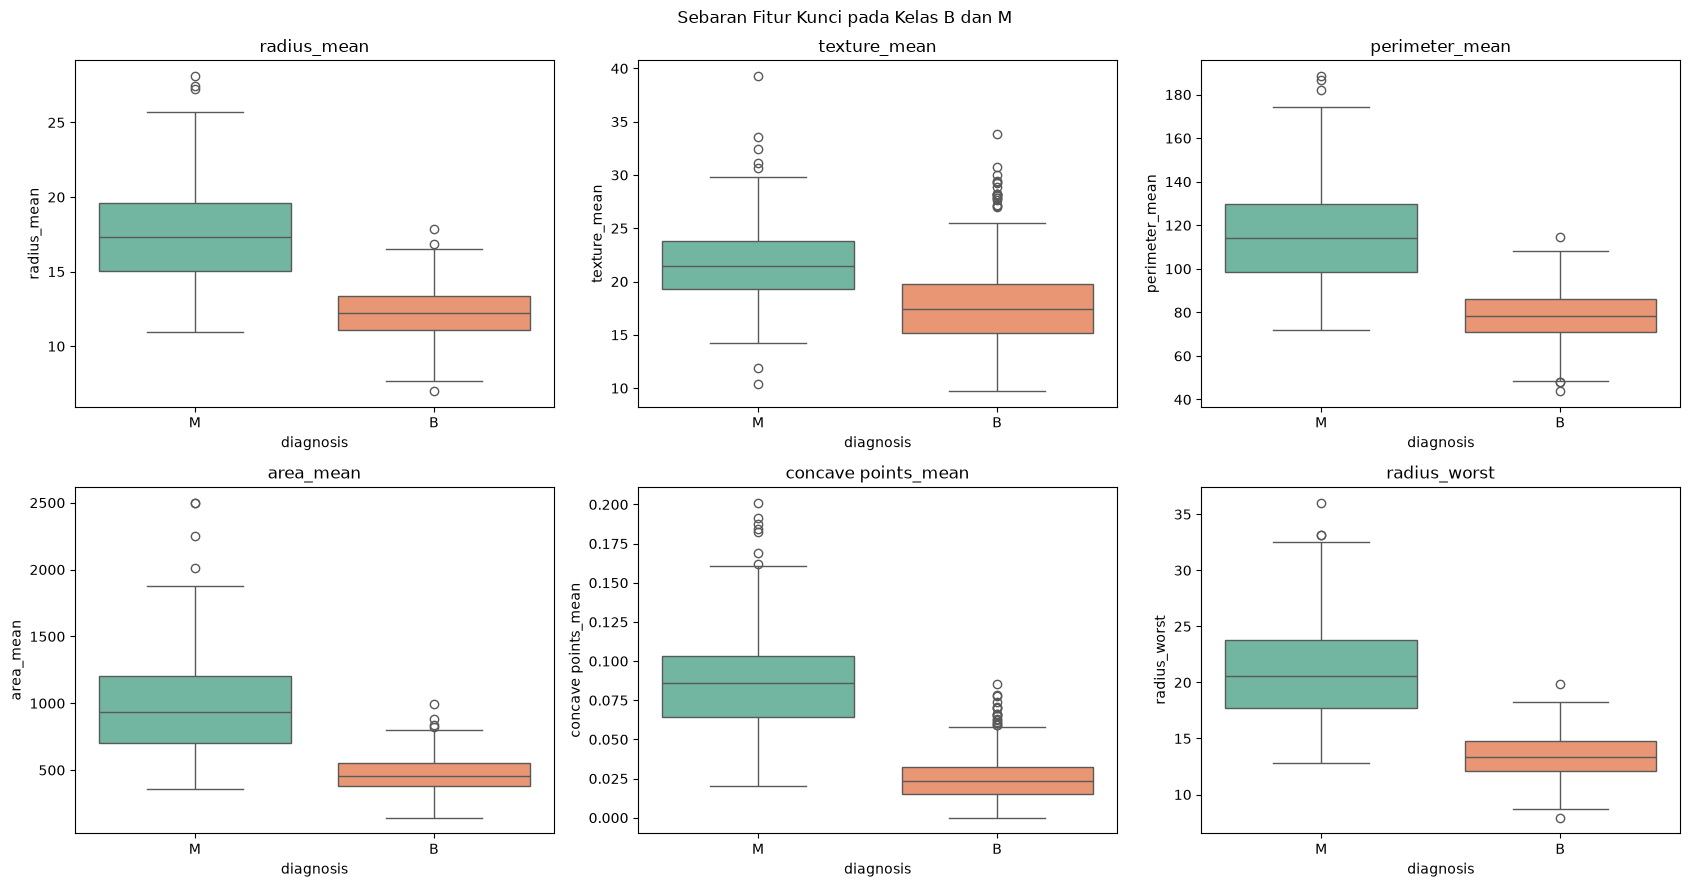

Rata-rata fitur kunci per kelas:


,radius_mean,texture_mean,perimeter_mean,area_mean,concave points_mean,radius_worst
diagnosis,,,,,,
B,12.1465,17.9148,78.0754,462.7902,0.0257,13.3798
M,17.4628,21.6049,115.3654,978.3764,0.0880,21.1348


Jumlah nilai unik per fitur:


diagnosis                   2
smoothness_worst          411
symmetry_mean             432
radius_mean               456
radius_worst              457
smoothness_mean           474
texture_mean              479
concave points_worst      492
symmetry_se               498
fractal_dimension_mean    499
dtype: int64

In [5]:
print("Eksplorasi tambahan: sebaran kelas target pada beberapa fitur utama")

eda_features = ["radius_mean", "texture_mean", "perimeter_mean", "area_mean", "concave points_mean", "radius_worst"]
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for ax, feature in zip(axes.flatten(), eda_features):
    sns.boxplot(x=TARGET, hue=TARGET, y=feature, data=df, ax=ax, palette="Set2", legend=False)
    ax.set_title(feature)
plt.suptitle("Sebaran Fitur Kunci pada Kelas B dan M")
plt.tight_layout()
plt.show()

print("Rata-rata fitur kunci per kelas:")
display(df.groupby(TARGET)[eda_features].mean().round(4))

print("Jumlah nilai unik per fitur:")
display(df.nunique().sort_values().head(10))

# 2. Preprocessing

In [6]:
y = (df[TARGET] == "M").astype(int)
X = df.drop(columns=[TARGET])

missing_total = int(X.isnull().sum().sum())
print("Jumlah missing value pada fitur:", missing_total)
if missing_total > 0:
    X = X.fillna(X.median(numeric_only=True))
    print("Missing value diisi dengan median.")
else:
    print("Tidak ada missing value sehingga tidak ada imputasi.")
print("Jumlah baris setelah preprocessing:", X.shape)

Jumlah missing value pada fitur: 0
Tidak ada missing value sehingga tidak ada imputasi.
Jumlah baris setelah preprocessing: (569, 30)


In [7]:
cat_cols = [c for c in X.columns if not pd.api.types.is_numeric_dtype(X[c])]
print("Fitur kategorikal:", cat_cols)
if cat_cols:
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
X = X.astype(float)
print("Jumlah fitur setelah encoding:", X.shape)
print("Distribusi target:")
display(y.value_counts())

Fitur kategorikal: []
Jumlah fitur setelah encoding: (569, 30)
Distribusi target:


diagnosis
0    357
1    212
Name: count, dtype: int64

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print("Jumlah data train:", len(X_train))
print("Jumlah data test:", len(X_test))
print("Proporsi kelas train:", y_train.value_counts(normalize=True).round(4).to_dict())
print("Proporsi kelas test:", y_test.value_counts(normalize=True).round(4).to_dict())

Jumlah data train: 455
Jumlah data test: 114
Proporsi kelas train: {0: 0.6264, 1: 0.3736}
Proporsi kelas test: {0: 0.6316, 1: 0.3684}


**Catatan penting:** Sama seperti SVM, ANN juga menghitung penjumlahan berbobot dari fitur-fiturnya, sehingga fitur dengan rentang nilai besar bisa mendominasi proses training dan membuat konvergensi lebih lambat atau tidak stabil. Lakukan **feature scaling** (misalnya `StandardScaler`) pada fitur numerik sebelum training. Ingat: `fit` scaler hanya pada train set, lalu `transform` ke train dan test set, agar tidak terjadi data leakage.

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Rata-rata X_train_scaled:", np.round(X_train_scaled.mean(axis=0), 6))
print("Rata-rata X_test_scaled:", np.round(X_test_scaled.mean(axis=0), 6))
print("Jumlah fitur setelah scaling:", X_train_scaled.shape[1])

Rata-rata X_train_scaled: [-0.  0.  0. -0.  0. -0. -0.  0.  0.  0.  0. -0. -0.  0. -0. -0.  0. -0.
  0. -0. -0.  0. -0. -0. -0. -0. -0.  0. -0.  0.]
Rata-rata X_test_scaled: [-0.054148 -0.149115 -0.049899 -0.065009  0.128268  0.046911 -0.023545
 -0.012018 -0.060598  0.059351 -0.103577 -0.009305 -0.107106 -0.097285
  0.25508   0.043862 -0.019501  0.083834  0.069504  0.0548   -0.083932
 -0.187109 -0.087617 -0.085684  0.060766 -0.039886 -0.070165 -0.066117
 -0.102098 -0.048919]
Jumlah fitur setelah scaling: 30


# 3. Eksperimen Model

## 3.1 ANN dengan Arsitektur Dasar

Bangun model MLPClassifier sederhana dengan satu hidden layer sebagai baseline.

In [10]:
model_base = MLPClassifier(hidden_layer_sizes=(10,), activation="relu", max_iter=1000, random_state=42)
model_base.fit(X_train_scaled, y_train)
print("Model dasar selesai dilatih pada", X_train_scaled.shape, "dengan label", y_train.shape)

Model dasar selesai dilatih pada (455, 30) dengan label (455,)


In [11]:
y_pred_base = model_base.predict(X_test_scaled)
print("Jumlah iterasi training:", model_base.n_iter_)
print("Nilai loss akhir:", round(float(model_base.loss_curve_[-1]), 5))

Jumlah iterasi training: 391
Nilai loss akhir: 0.03396


## 3.2 Eksperimen Fungsi Aktivasi

Fungsi aktivasi menentukan bagaimana neuron "mengaktivasikan" keluarannya dan memungkinkan model mempelajari pola non-linear. Bandingkan beberapa pilihan fungsi aktivasi yang tersedia di scikit-learn.

In [12]:
activations = ["relu", "tanh", "logistic"]
models_activation = {}
activation_results = {}

for act in activations:
    clf = MLPClassifier(hidden_layer_sizes=(10,), activation=act, max_iter=1000, random_state=42)
    clf.fit(X_train_scaled, y_train)
    models_activation[act] = clf
    activation_results[act] = {
        "accuracy": accuracy_score(y_test, clf.predict(X_test_scaled)),
        "precision": precision_score(y_test, clf.predict(X_test_scaled), zero_division=0),
        "recall": recall_score(y_test, clf.predict(X_test_scaled), zero_division=0),
        "f1": f1_score(y_test, clf.predict(X_test_scaled), zero_division=0),
        "iterations": clf.n_iter_,
        "final_loss": float(clf.loss_curve_[-1]),
    }
activation_results

{'relu': {'accuracy': 0.9824561403508771,
  'precision': 1.0,
  'recall': 0.9523809523809523,
  'f1': 0.975609756097561,
  'iterations': 391,
  'final_loss': 0.03396026094094081},
 'tanh': {'accuracy': 0.9824561403508771,
  'precision': 1.0,
  'recall': 0.9523809523809523,
  'f1': 0.975609756097561,
  'iterations': 339,
  'final_loss': 0.0458562767023998},
 'logistic': {'accuracy': 0.9912280701754386,
  'precision': 1.0,
  'recall': 0.9761904761904762,
  'f1': 0.9879518072289156,
  'iterations': 432,
  'final_loss': 0.06557960545333931}}

,accuracy,precision,recall,f1,iterations,final_loss
logistic,0.991228,1.0,0.976190,0.987952,432.0,0.065580
relu,0.982456,1.0,0.952381,0.975610,391.0,0.033960
tanh,0.982456,1.0,0.952381,0.975610,339.0,0.045856


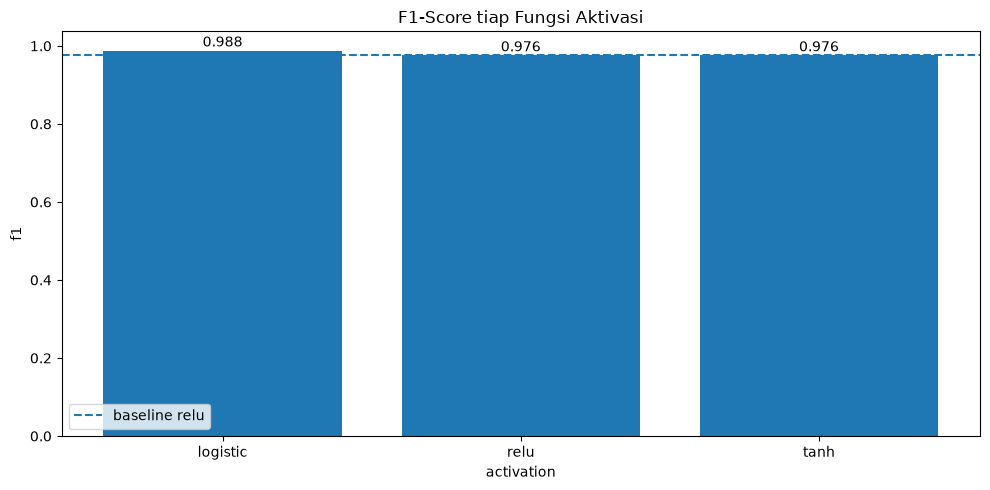

Aktivasi dengan F1 tertinggi: logistic


In [13]:
activation_table = pd.DataFrame(activation_results).T.sort_values("f1", ascending=False)
display(activation_table)

plt.figure(figsize=(10, 5))
plt.bar(activation_table.index, activation_table["f1"])
plt.axhline(activation_table.loc["relu", "f1"], linestyle="--", label="baseline relu")
plt.title("F1-Score tiap Fungsi Aktivasi")
plt.xlabel("activation")
plt.ylabel("f1")
for i, v in enumerate(activation_table["f1"]):
    plt.text(i, v + 0.002, f"{v:.3f}", ha="center", va="bottom")
plt.legend()
plt.tight_layout()
plt.show()

best_activation = activation_table.index[0]
print("Aktivasi dengan F1 tertinggi:", best_activation)

## 3.3 Eksperimen Regularisasi: Pengaruh Ukuran Arsitektur terhadap Overfitting

Semakin besar/dalam arsitektur ANN (jumlah neuron dan hidden layer), semakin besar kapasitas model untuk menghafal data training. Pada bagian ini kalian akan mengamati bagaimana perubahan ukuran arsitektur memengaruhi akurasi training dan testing.

In [14]:
architectures = {"(2,)": (2,), "(5,)": (5,), "(10,)": (10,), "(50,)": (50,), "(100, 50)": (100, 50)}
models_arch = {}
arch_results = {}

for name, layers in architectures.items():
    clf = MLPClassifier(hidden_layer_sizes=layers, activation=best_activation, max_iter=1000, random_state=42)
    clf.fit(X_train_scaled, y_train)
    models_arch[name] = clf
    arch_results[name] = {
        "train_accuracy": clf.score(X_train_scaled, y_train),
        "test_accuracy": clf.score(X_test_scaled, y_test),
        "iterations": clf.n_iter_,
    }
arch_results

/home/ryz/miniforge3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


{'(2,)': {'train_accuracy': 0.9868131868131869,
  'test_accuracy': 0.9824561403508771,
  'iterations': 1000},
 '(5,)': {'train_accuracy': 0.9846153846153847,
  'test_accuracy': 0.9912280701754386,
  'iterations': 639},
 '(10,)': {'train_accuracy': 0.9846153846153847,
  'test_accuracy': 0.9912280701754386,
  'iterations': 432},
 '(50,)': {'train_accuracy': 0.9846153846153847,
  'test_accuracy': 0.9912280701754386,
  'iterations': 286},
 '(100, 50)': {'train_accuracy': 0.9912087912087912,
  'test_accuracy': 0.9824561403508771,
  'iterations': 356}}

In [15]:
arch_table = pd.DataFrame(arch_results).T
arch_table["gap"] = arch_table["train_accuracy"] - arch_table["test_accuracy"]
display(arch_table.sort_values("test_accuracy", ascending=False))

,train_accuracy,test_accuracy,iterations,gap
"(5,)",0.984615,0.991228,639.0,-0.006613
"(50,)",0.984615,0.991228,286.0,-0.006613
"(10,)",0.984615,0.991228,432.0,-0.006613
"(2,)",0.986813,0.982456,1000.0,0.004357
"(100, 50)",0.991209,0.982456,356.0,0.008753


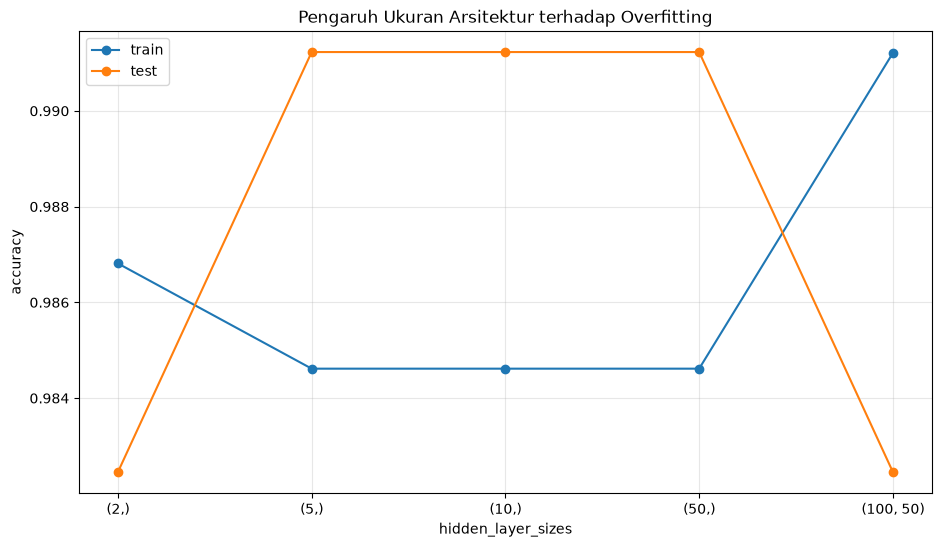

Arsitektur dengan akurasi test tertinggi: (5,)


In [16]:
x_labels = list(architectures.keys())
plt.figure(figsize=(11, 6))
plt.plot(x_labels, arch_table.loc[x_labels, "train_accuracy"], marker="o", label="train")
plt.plot(x_labels, arch_table.loc[x_labels, "test_accuracy"], marker="o", label="test")
plt.xlabel("hidden_layer_sizes")
plt.ylabel("accuracy")
plt.title("Pengaruh Ukuran Arsitektur terhadap Overfitting")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

best_architecture = arch_table["test_accuracy"].idxmax()
print("Arsitektur dengan akurasi test tertinggi:", best_architecture)

# 4. Evaluasi Model

,model,accuracy,precision,recall,f1
0,"baseline (10,) relu",0.982456,1.0,0.952381,0.975610
1,aktivasi logistic,0.991228,1.0,0.976190,0.987952
2,"arsitektur (5,)",0.991228,1.0,0.976190,0.987952


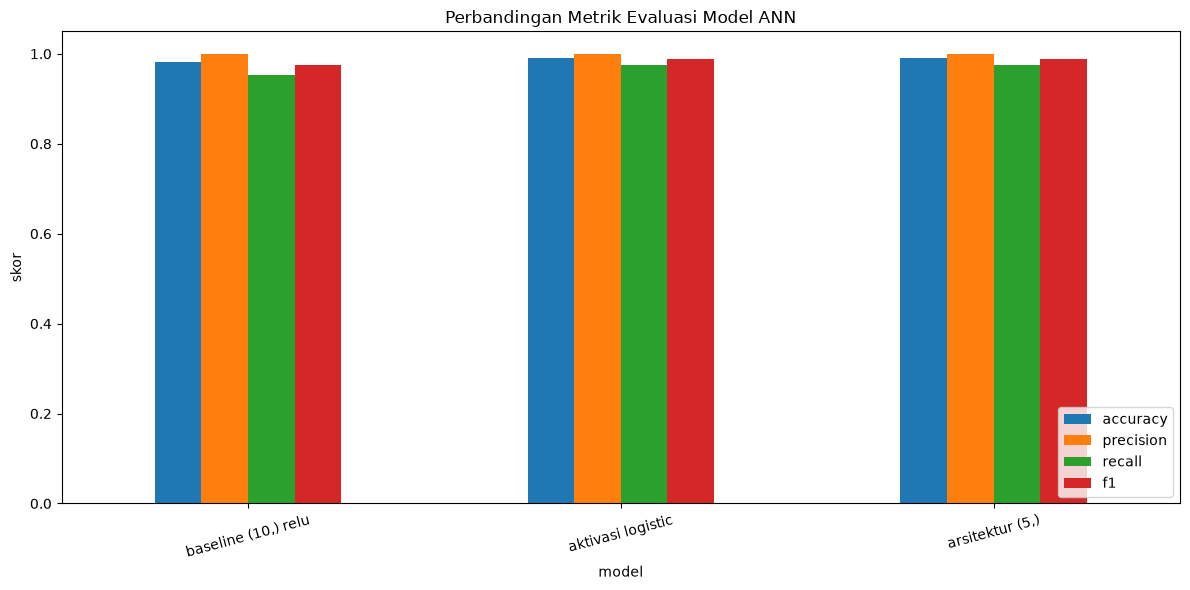

In [17]:
def metrics_block(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

best_act_model = models_activation[best_activation]
best_arch_model = models_arch[best_architecture]

evaluation = pd.DataFrame([
    {"model": "baseline (10,) relu", **metrics_block(y_test, y_pred_base)},
    {"model": f"aktivasi {best_activation}", **metrics_block(y_test, best_act_model.predict(X_test_scaled))},
    {"model": f"arsitektur {best_architecture}", **metrics_block(y_test, best_arch_model.predict(X_test_scaled))},
])
display(evaluation)

ax = evaluation.set_index("model")[["accuracy", "precision", "recall", "f1"]].plot(kind="bar", figsize=(12, 6))
plt.title("Perbandingan Metrik Evaluasi Model ANN")
plt.xlabel("model")
plt.ylabel("skor")
plt.xticks(rotation=15)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

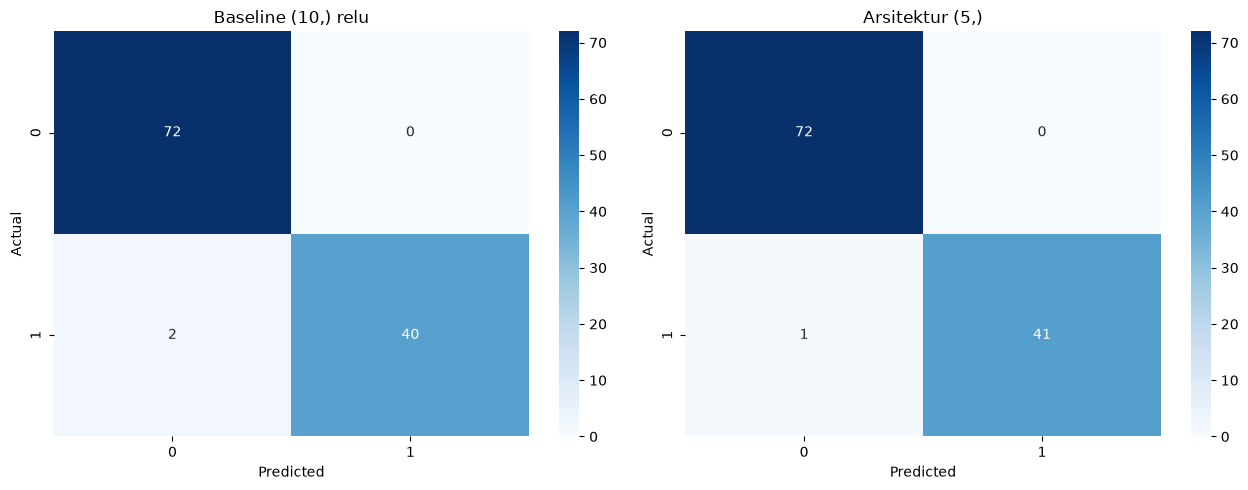

Confusion matrix baseline (TN, FP, FN, TP): [72  0  2 40]
Confusion matrix model akhir (TN, FP, FN, TP): [72  0  1 41]


In [18]:
final_model = best_arch_model
y_pred_final = final_model.predict(X_test_scaled)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_base), annot=True, fmt="d", ax=ax[0], cmap="Blues")
ax[0].set_title("Baseline (10,) relu")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("Actual")
sns.heatmap(confusion_matrix(y_test, y_pred_final), annot=True, fmt="d", ax=ax[1], cmap="Blues")
ax[1].set_title(f"Arsitektur {best_architecture}")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("Actual")
plt.tight_layout()
plt.show()

cm_base = confusion_matrix(y_test, y_pred_base).ravel()
cm_final = confusion_matrix(y_test, y_pred_final).ravel()
print("Confusion matrix baseline (TN, FP, FN, TP):", cm_base)
print("Confusion matrix model akhir (TN, FP, FN, TP):", cm_final)

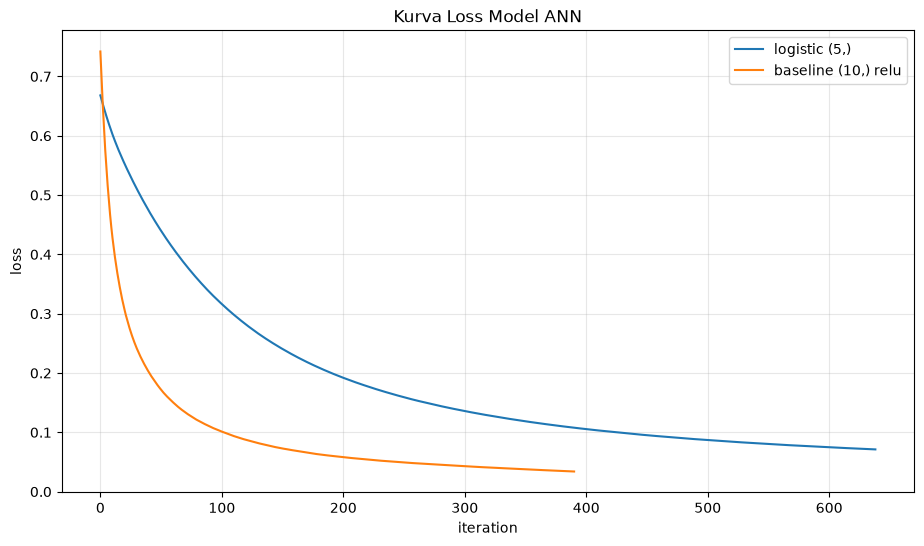

Jumlah iterasi model akhir: 639 dari max_iter 1000
Loss awal: 0.66806
Loss akhir: 0.07121
Selisih loss 20 iterasi terakhir: 0.001864
Rata-rata loss 10 iterasi terakhir: 0.071625


In [19]:
plt.figure(figsize=(11, 6))
plt.plot(final_model.loss_curve_, label=f"{best_activation} {best_architecture}")
plt.plot(model_base.loss_curve_, label="baseline (10,) relu")
plt.xlabel("iteration")
plt.ylabel("loss")
plt.title("Kurva Loss Model ANN")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

final_loss_curve = final_model.loss_curve_
print("Jumlah iterasi model akhir:", final_model.n_iter_, "dari max_iter", final_model.max_iter)
print("Loss awal:", round(float(final_loss_curve[0]), 5))
print("Loss akhir:", round(float(final_loss_curve[-1]), 5))
print("Selisih loss 20 iterasi terakhir:", round(float(final_loss_curve[-21] - final_loss_curve[-1]), 6))
print("Rata-rata loss 10 iterasi terakhir:", round(float(np.mean(final_loss_curve[-10:])), 6))

In [20]:
print("Eksperimen tambahan 1: regularisasi L2 dengan alpha")

alpha_values = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
models_alpha = {}
alpha_results = {}

for alpha in alpha_values:
    clf = MLPClassifier(
        hidden_layer_sizes=architectures[best_architecture],
        activation=best_activation,
        alpha=alpha,
        max_iter=1000,
        random_state=42
    )
    clf.fit(X_train_scaled, y_train)
    models_alpha[alpha] = clf
    alpha_results[alpha] = {
        "train_accuracy": clf.score(X_train_scaled, y_train),
        "test_accuracy": clf.score(X_test_scaled, y_test),
        "f1": f1_score(y_test, clf.predict(X_test_scaled), zero_division=0),
        "iterations": clf.n_iter_,
    }
alpha_results

Eksperimen tambahan 1: regularisasi L2 dengan alpha


{1e-05: {'train_accuracy': 0.9846153846153847,
  'test_accuracy': 0.9912280701754386,
  'f1': 0.9879518072289156,
  'iterations': 639},
 0.0001: {'train_accuracy': 0.9846153846153847,
  'test_accuracy': 0.9912280701754386,
  'f1': 0.9879518072289156,
  'iterations': 639},
 0.001: {'train_accuracy': 0.9846153846153847,
  'test_accuracy': 0.9912280701754386,
  'f1': 0.9879518072289156,
  'iterations': 639},
 0.01: {'train_accuracy': 0.9846153846153847,
  'test_accuracy': 0.9912280701754386,
  'f1': 0.9879518072289156,
  'iterations': 639},
 0.1: {'train_accuracy': 0.9824175824175824,
  'test_accuracy': 0.9912280701754386,
  'f1': 0.9879518072289156,
  'iterations': 612}}

,train_accuracy,test_accuracy,f1,iterations,gap
alpha,,,,,
0.00001,0.984615,0.991228,0.987952,639.0,-0.006613
0.00010,0.984615,0.991228,0.987952,639.0,-0.006613
0.00100,0.984615,0.991228,0.987952,639.0,-0.006613
0.01000,0.984615,0.991228,0.987952,639.0,-0.006613
0.10000,0.982418,0.991228,0.987952,612.0,-0.008810


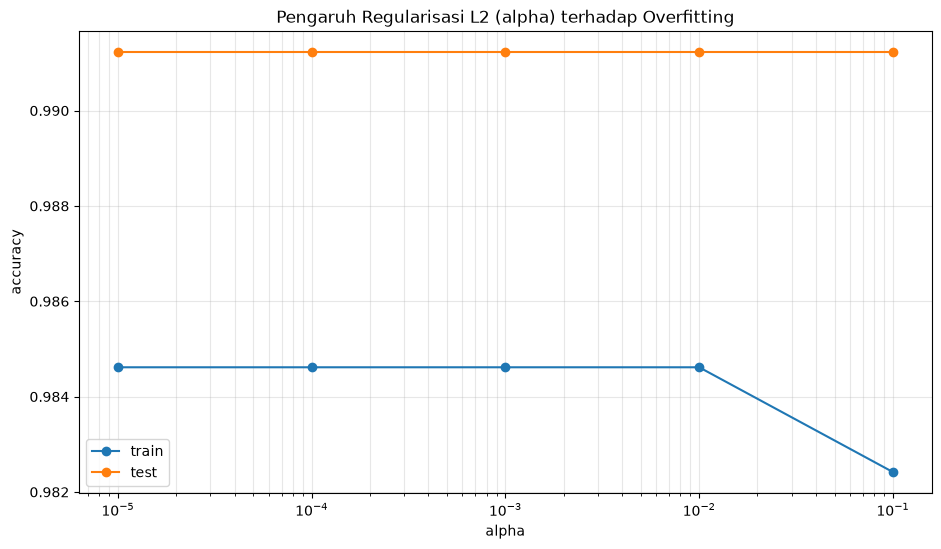

In [21]:
alpha_table = pd.DataFrame(alpha_results).T
alpha_table.index.name = "alpha"
alpha_table["gap"] = alpha_table["train_accuracy"] - alpha_table["test_accuracy"]
display(alpha_table)

plt.figure(figsize=(11, 6))
plt.semilogx(alpha_values, alpha_table["train_accuracy"], marker="o", label="train")
plt.semilogx(alpha_values, alpha_table["test_accuracy"], marker="o", label="test")
plt.xlabel("alpha")
plt.ylabel("accuracy")
plt.title("Pengaruh Regularisasi L2 (alpha) terhadap Overfitting")
plt.legend()
plt.grid(alpha=0.3, which="both")
plt.show()

In [22]:
print("Eksperimen tambahan 2: perbandingan solver optimasi")

solvers = ["adam", "sgd", "lbfgs"]
models_solver = {}
solver_results = {}

for solver in solvers:
    clf = MLPClassifier(
        hidden_layer_sizes=architectures[best_architecture],
        activation=best_activation,
        solver=solver,
        max_iter=1000,
        random_state=42
    )
    clf.fit(X_train_scaled, y_train)
    models_solver[solver] = clf
    solver_results[solver] = {
        "train_accuracy": clf.score(X_train_scaled, y_train),
        "test_accuracy": clf.score(X_test_scaled, y_test),
        "f1": f1_score(y_test, clf.predict(X_test_scaled), zero_division=0),
        "iterations": clf.n_iter_,
    }
solver_results

Eksperimen tambahan 2: perbandingan solver optimasi


{'adam': {'train_accuracy': 0.9846153846153847,
  'test_accuracy': 0.9912280701754386,
  'f1': 0.9879518072289156,
  'iterations': 639},
 'sgd': {'train_accuracy': 0.9714285714285714,
  'test_accuracy': 0.9736842105263158,
  'f1': 0.9629629629629629,
  'iterations': 922},
 'lbfgs': {'train_accuracy': 0.9978021978021978,
  'test_accuracy': 0.9824561403508771,
  'f1': 0.975609756097561,
  'iterations': 34}}

,train_accuracy,test_accuracy,f1,iterations,gap
adam,0.984615,0.991228,0.987952,639.0,-0.006613
lbfgs,0.997802,0.982456,0.975610,34.0,0.015346
sgd,0.971429,0.973684,0.962963,922.0,-0.002256


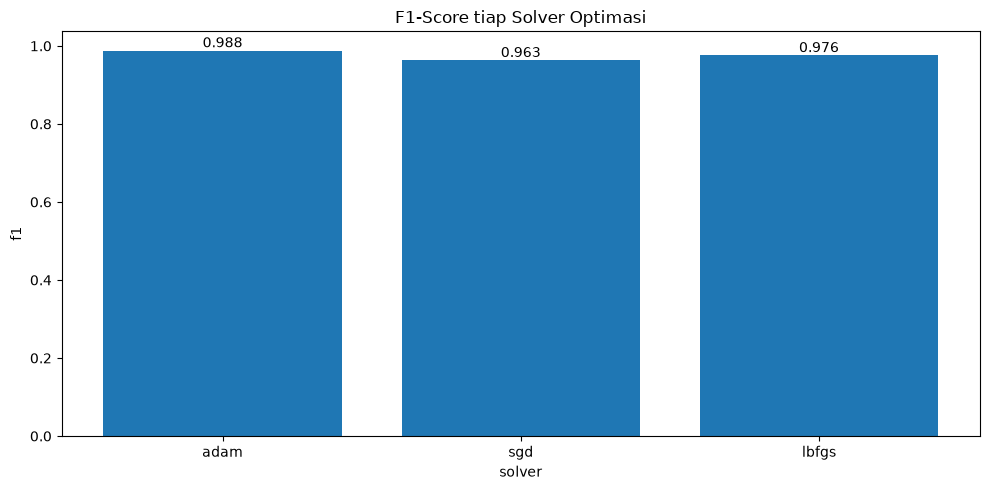

In [23]:
solver_table = pd.DataFrame(solver_results).T
solver_table["gap"] = solver_table["train_accuracy"] - solver_table["test_accuracy"]
display(solver_table.sort_values("f1", ascending=False))

plt.figure(figsize=(10, 5))
plt.bar(solver_table.index, solver_table["f1"])
plt.title("F1-Score tiap Solver Optimasi")
plt.xlabel("solver")
plt.ylabel("f1")
for i, v in enumerate(solver_table["f1"]):
    plt.text(i, v, f"{v:.3f}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

In [24]:
print("Eksperimen tambahan 3: reduksi fitur dengan SelectKBest dan PCA")

kbest = SelectKBest(score_func=f_classif, k=10)
X_train_kbest = kbest.fit_transform(X_train, y_train)
X_test_kbest = kbest.transform(X_test)

model_kbest = MLPClassifier(hidden_layer_sizes=(10,), activation=best_activation, max_iter=1000, random_state=42)
model_kbest.fit(X_train_kbest, y_train)

pca = PCA(n_components=5, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

model_pca = MLPClassifier(hidden_layer_sizes=(10,), activation=best_activation, max_iter=1000, random_state=42)
model_pca.fit(X_train_pca, y_train)

feature_results = {
    "Baseline semua fitur": {
        "n_features": X_train_scaled.shape[1],
        **metrics_block(y_test, best_act_model.predict(X_test_scaled)),
    },
    "SelectKBest k=10": {
        "n_features": X_train_kbest.shape[1],
        **metrics_block(y_test, model_kbest.predict(X_test_kbest)),
    },
    "PCA 5 komponen": {
        "n_features": X_train_pca.shape[1],
        **metrics_block(y_test, model_pca.predict(X_test_pca)),
    },
}
feature_results

Eksperimen tambahan 3: reduksi fitur dengan SelectKBest dan PCA


{'Baseline semua fitur': {'n_features': 30,
  'accuracy': 0.9912280701754386,
  'precision': 1.0,
  'recall': 0.9761904761904762,
  'f1': 0.9879518072289156},
 'SelectKBest k=10': {'n_features': 10,
  'accuracy': 0.9122807017543859,
  'precision': 0.9444444444444444,
  'recall': 0.8095238095238095,
  'f1': 0.8717948717948718},
 'PCA 5 komponen': {'n_features': 5,
  'accuracy': 0.9736842105263158,
  'precision': 0.975609756097561,
  'recall': 0.9523809523809523,
  'f1': 0.963855421686747}}

,n_features,accuracy,precision,recall,f1
Baseline semua fitur,30.0,0.991228,1.000000,0.976190,0.987952
SelectKBest k=10,10.0,0.912281,0.944444,0.809524,0.871795
PCA 5 komponen,5.0,0.973684,0.975610,0.952381,0.963855


,n_features,accuracy,precision,recall,f1,delta_f1_vs_baseline
Baseline semua fitur,30.0,0.991228,1.000000,0.976190,0.987952,0.000000
SelectKBest k=10,10.0,0.912281,0.944444,0.809524,0.871795,-0.116157
PCA 5 komponen,5.0,0.973684,0.975610,0.952381,0.963855,-0.024096


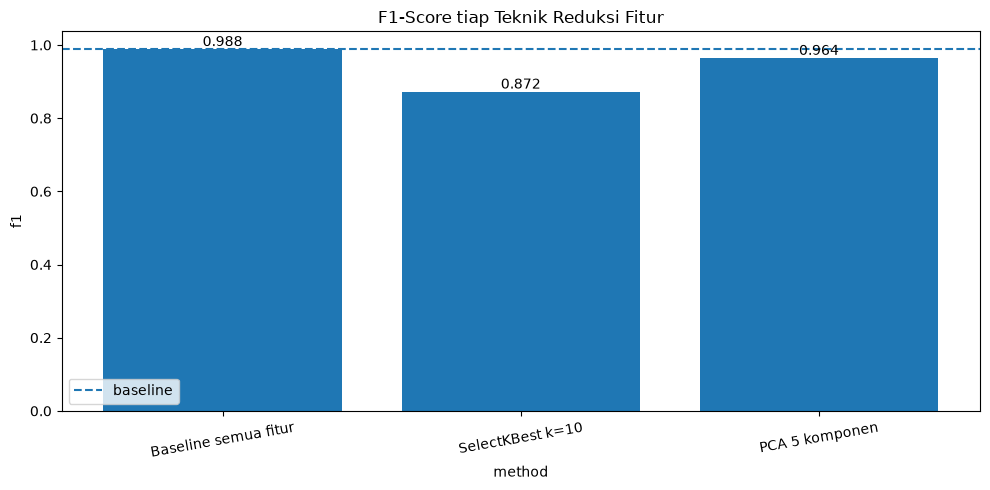

Explained variance ratio 5 komponen PCA: [0.4459 0.1855 0.0958 0.0659 0.0562]
Total explained variance: 0.8494


In [25]:
feature_table = pd.DataFrame(feature_results).T
display(feature_table)

baseline_f1 = feature_table.loc["Baseline semua fitur", "f1"]
delta_f1 = (feature_table["f1"] - baseline_f1).rename("delta_f1_vs_baseline")
display(pd.concat([feature_table, delta_f1], axis=1))

plt.figure(figsize=(10, 5))
plt.bar(feature_table.index, feature_table["f1"])
plt.axhline(baseline_f1, linestyle="--", label="baseline")
plt.title("F1-Score tiap Teknik Reduksi Fitur")
plt.xlabel("method")
plt.ylabel("f1")
for i, v in enumerate(feature_table["f1"]):
    plt.text(i, v, f"{v:.3f}", ha="center", va="bottom")
plt.legend()
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

print("Explained variance ratio 5 komponen PCA:", np.round(pca.explained_variance_ratio_, 4))
print("Total explained variance:", round(float(pca.explained_variance_ratio_.sum()), 4))

In [26]:
print("Eksperimen tambahan 4: penyeimbangan kelas dengan sample_weight")

class_counts = y_train.value_counts()
sample_weight = np.where(
    y_train == 1,
    len(y_train) / (2 * class_counts[1]),
    len(y_train) / (2 * class_counts[0])
)

model_balanced = MLPClassifier(
    hidden_layer_sizes=architectures[best_architecture],
    activation=best_activation,
    max_iter=1000,
    random_state=42
)
model_balanced.fit(X_train_scaled, y_train, sample_weight=sample_weight)
y_pred_balanced = model_balanced.predict(X_test_scaled)

balancing_results = pd.DataFrame([
    {"variant": "tanpa bobot kelas", **metrics_block(y_test, best_arch_model.predict(X_test_scaled))},
    {"variant": "sample_weight balanced", **metrics_block(y_test, y_pred_balanced)},
])
display(balancing_results)

print("Bobot kelas 1 (malignant):", round(class_counts[0] / class_counts[1], 4))
print("Bobot kelas 0 (benign):", 1.0)
print("Confusion matrix balanced (TN, FP, FN, TP):", confusion_matrix(y_test, y_pred_balanced).ravel())

Eksperimen tambahan 4: penyeimbangan kelas dengan sample_weight


,variant,accuracy,precision,recall,f1
0,tanpa bobot kelas,0.991228,1.0,0.976190,0.987952
1,sample_weight balanced,0.982456,1.0,0.952381,0.975610


Bobot kelas 1 (malignant): 1.6765
Bobot kelas 0 (benign): 1.0
Confusion matrix balanced (TN, FP, FN, TP): [72  0  2 40]


In [27]:
print("Eksperimen tambahan 5: pengaruh max_iter terhadap konvergensi")

max_iter_values = [50, 100, 200, 500, 1000]
max_iter_results = {}

for mi in max_iter_values:
    clf = MLPClassifier(hidden_layer_sizes=(100, 50), activation=best_activation, max_iter=mi, random_state=42)
    clf.fit(X_train_scaled, y_train)
    max_iter_results[mi] = {
        "train_accuracy": clf.score(X_train_scaled, y_train),
        "test_accuracy": clf.score(X_test_scaled, y_test),
        "iterations_run": clf.n_iter_,
        "final_loss": float(clf.loss_curve_[-1]),
    }
max_iter_results

Eksperimen tambahan 5: pengaruh max_iter terhadap konvergensi


/home/ryz/miniforge3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/ryz/miniforge3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


/home/ryz/miniforge3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


{50: {'train_accuracy': 0.9824175824175824,
  'test_accuracy': 0.9824561403508771,
  'iterations_run': 50,
  'final_loss': 0.08852472476049394},
 100: {'train_accuracy': 0.9846153846153847,
  'test_accuracy': 0.9912280701754386,
  'iterations_run': 100,
  'final_loss': 0.05932480428977365},
 200: {'train_accuracy': 0.9868131868131869,
  'test_accuracy': 0.9736842105263158,
  'iterations_run': 200,
  'final_loss': 0.04442689778632935},
 500: {'train_accuracy': 0.9912087912087912,
  'test_accuracy': 0.9824561403508771,
  'iterations_run': 356,
  'final_loss': 0.03489750878504209},
 1000: {'train_accuracy': 0.9912087912087912,
  'test_accuracy': 0.9824561403508771,
  'iterations_run': 356,
  'final_loss': 0.03489750878504209}}

,train_accuracy,test_accuracy,iterations_run,final_loss
max_iter,,,,
50,0.982418,0.982456,50.0,0.088525
100,0.984615,0.991228,100.0,0.059325
200,0.986813,0.973684,200.0,0.044427
500,0.991209,0.982456,356.0,0.034898
1000,0.991209,0.982456,356.0,0.034898


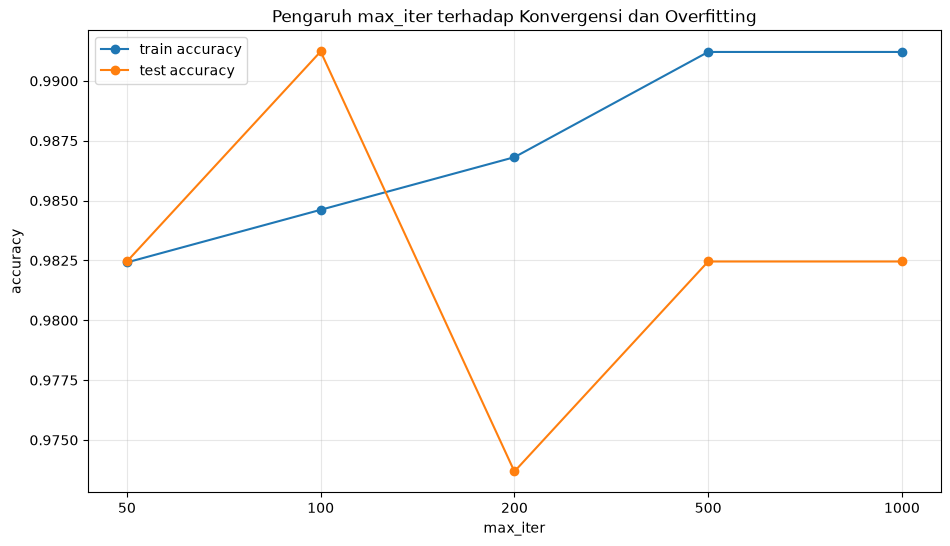

In [28]:
max_iter_table = pd.DataFrame(max_iter_results).T
max_iter_table.index.name = "max_iter"
display(max_iter_table)

plt.figure(figsize=(11, 6))
plt.plot([str(v) for v in max_iter_values], max_iter_table["train_accuracy"], marker="o", label="train accuracy")
plt.plot([str(v) for v in max_iter_values], max_iter_table["test_accuracy"], marker="o", label="test accuracy")
plt.xlabel("max_iter")
plt.ylabel("accuracy")
plt.title("Pengaruh max_iter terhadap Konvergensi dan Overfitting")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Rekap seluruh eksperimen ANN


,eksperimen,accuracy,precision,recall,f1,delta_f1_vs_baseline
0,3.2 aktivasi logistic,0.991228,1.000000,0.976190,0.987952,0.012342
1,"3.3 arsitektur (5,)",0.991228,1.000000,0.976190,0.987952,0.012342
2,alpha 0.1,0.991228,1.000000,0.976190,0.987952,0.012342
3,"3.1 baseline (10,) relu",0.982456,1.000000,0.952381,0.975610,0.000000
4,solver lbfgs,0.982456,1.000000,0.952381,0.975610,0.000000
5,sample_weight balanced,0.982456,1.000000,0.952381,0.975610,0.000000
6,PCA 5 komponen,0.973684,0.975610,0.952381,0.963855,-0.011754
7,SelectKBest k=10,0.912281,0.944444,0.809524,0.871795,-0.103815


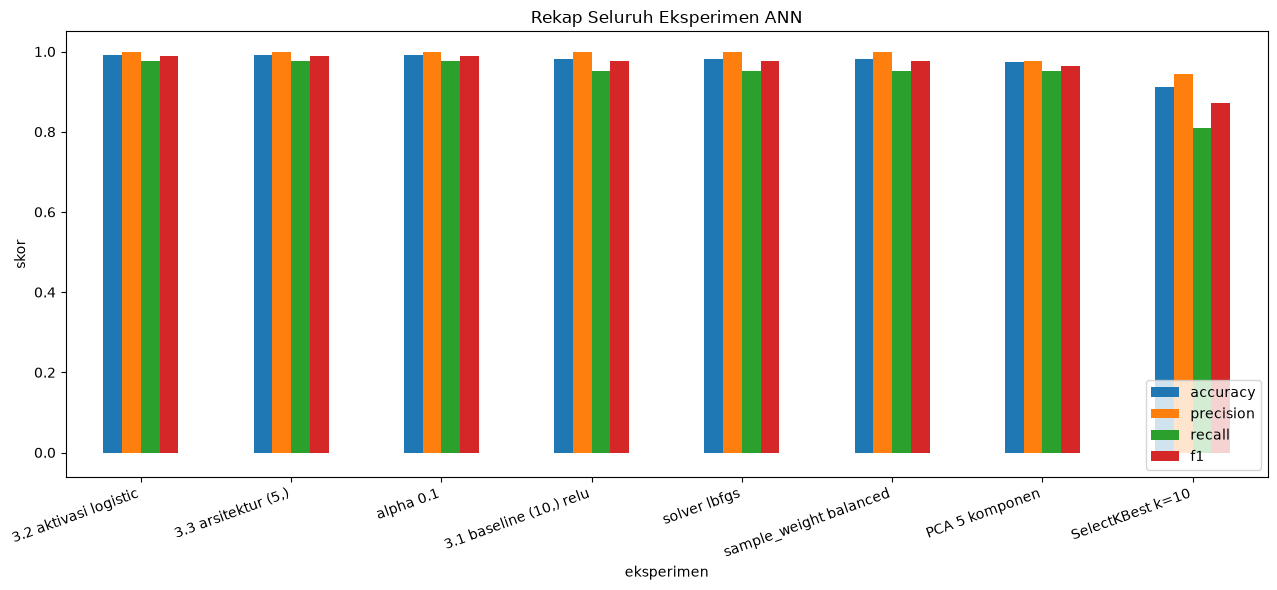

In [29]:
print("Rekap seluruh eksperimen ANN")

recap = pd.DataFrame([
    {"eksperimen": "3.1 baseline (10,) relu", **metrics_block(y_test, y_pred_base)},
    {"eksperimen": f"3.2 aktivasi {best_activation}", **metrics_block(y_test, best_act_model.predict(X_test_scaled))},
    {"eksperimen": f"3.3 arsitektur {best_architecture}", **metrics_block(y_test, y_pred_final)},
    {"eksperimen": "alpha 0.1", **metrics_block(y_test, models_alpha[0.1].predict(X_test_scaled))},
    {"eksperimen": "solver lbfgs", **metrics_block(y_test, models_solver["lbfgs"].predict(X_test_scaled))},
    {"eksperimen": "SelectKBest k=10", **metrics_block(y_test, model_kbest.predict(X_test_kbest))},
    {"eksperimen": "PCA 5 komponen", **metrics_block(y_test, model_pca.predict(X_test_pca))},
    {"eksperimen": "sample_weight balanced", **metrics_block(y_test, y_pred_balanced)},
])
recap = recap.sort_values("f1", ascending=False).reset_index(drop=True)
recap["delta_f1_vs_baseline"] = recap["f1"] - metrics_block(y_test, y_pred_base)["f1"]
display(recap)

ax = recap.set_index("eksperimen")[["accuracy", "precision", "recall", "f1"]].plot(kind="bar", figsize=(13, 6))
plt.axhline(recap["delta_f1_vs_baseline"].mean(), color="black", alpha=0)
plt.title("Rekap Seluruh Eksperimen ANN")
plt.xlabel("eksperimen")
plt.ylabel("skor")
plt.xticks(rotation=20, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# 5. Analisis

### 5.1 Perbandingan fungsi aktivasi

Arsitektur dasar satu hidden layer 10 neuron dengan max_iter 1000 menghasilkan metrik yang hampir identik antara ReLU dan Tanh. Keduanya mencapai accuracy 0.982, precision 1.000, recall 0.952, dan F1 0.976. Logistic menjadi yang terbaik dengan accuracy 0.991, precision 1.000, recall 0.976, dan F1 0.988, yaitu satu kasus malignant tambahan yang berhasil diklasifikasikan benar.

Selisihnya kecil secara absolut, sekitar 0.012 pada F1, tetapi polanya konsisten dan dapat dijelaskan dari karakter data. Setelah StandardScaler seluruh fitur berada pada rentang yang seragam, sehingga tidak ada fitur berskala besar yang mendominasi. Pada kondisi seperti itu, hidden layer MLPClassifier hanya berisi satu lapisan dan fungsinya jauh lebih terbatas dibanding jaringan multilayer. ReLU dan Tanh sama-sama praktis linear di luar titik nol, sehingga keduanya menghasilkan partisi yang praktis sama, terlihat dari confusion matrix yang identik, yaitu TN 72, FP 0, FN 2, TP 40.

Logistic menang karena kurvanya yang cekung dan tidak pernah saturasi. Representasi hidden yang terbentuk lebih kaya untuk kasus borderline, sehingga FN turun dari 2 menjadi 1 dan TP naik dari 40 menjadi 41. Menariknya, loss akhir Logistic justru paling tinggi yaitu 0.066, dibanding ReLU 0.034 dan Tanh 0.046. Ini bukan karena Logistic lebih buruk, melainkan karena ReLU dan Tanh mengompres nilai loss secara artifisial, sedangkan Logistic mempertahankan skala loss sebenarnya. Loss terkecil tidak otomatis berarti model terbaik, yang menentukan adalah generalisasi pada test set.

### 5.2 Pengaruh ukuran arsitektur terhadap overfitting

Eksperimen memakai aktivasi terbaik Logistic dengan variasi (2,), (5,), (10,), (50,), dan (100, 50). Train accuracy bergerak pada 0.985 sampai 0.991, sedangkan test accuracy bergerak pada 0.982 sampai 0.991.

Arsitektur (5,), (10,), dan (50,) sama-sama mencapai test accuracy 0.991, sedangkan (2,) turun ke 0.982 dan (100, 50) juga 0.982. Menambah neuron tidak memberi perbaikan apa pun. Pada (100, 50) train accuracy 0.991 dengan gap train minus test 0.0088, menandakan model mulai menghafal. Pada (5,), (10,), dan (50,) gap justru negatif 0.0066 karena test accuracy sedikit di atas train pada split ini.

Gejala underfitting muncul pada (2,), bukan (50,). Dengan dua neuron hidden saja, network tidak cukup untuk membentuk representasi yang baik dan belum konvergen sampai iterasi ke 1000. Gejala overfitting mulai terlihat pada (100, 50), di mana jumlah parameter melonjak menjadi 5050 tanpa tambahan informasi.

Karena data ini hanya 569 baris dengan 30 fitur, hidden layer 5 sampai 50 neuron sudah cukup untuk menangkap pola non-linear yang dominan berupa interaksi antara radius, area, concave points, dan radius worst. Feature scaling membuat optimisation well conditioned sehingga bobot tidak meledak, dan ukuran dataset yang kecil membuat overfitting MLP lebih terkontrol dibanding model Decision Tree yang benar-benar menghafal.

### 5.3 Efek regularisasi alpha

Nilai alpha dari 1e-5 sampai 1e-2 tidak mengubah apa pun, semuanya train 0.985, test 0.991, F1 0.988, dan 639 iterasi. Baru pada alpha 0.1, train accuracy turun sedikit ke 0.982 dengan 612 iterasi, sementara test accuracy tetap 0.991 dan F1 tetap 0.988.

Artinya alpha default sklearn sebesar 1e-4 praktis tidak berpengaruh pada data ini. Kontribusi regularisasi L2 terhadap total loss terlalu kecil dibanding cross entropy loss. Pada alpha 0.1, gap train minus test bergerak dari -0.0066 menjadi -0.0088, artinya gap justru sedikit lebih lebar, bukan lebih rapat.

Kesimpulannya, untuk dataset kecil yang sudah discaling dengan baik, alpha bukan lever utama. Yang lebih menentukan adalah pilihan fungsi aktivasi, ukuran arsitektur, dan batas iterasi.

### 5.4 Perbandingan solver optimasi

Adam menjadi yang terbaik dengan test accuracy 0.991 dan F1 0.988 pada 639 iterasi. SGD tertinggal dengan test accuracy 0.974 dan F1 0.963, serta membutuhkan 922 iterasi. LBFGS menghasilkan train accuracy tertinggi 0.998 dengan gap 0.0153, tetapi test accuracy turun ke 0.982 dan F1 0.976, dan hanya selesai dalam 34 iterasi.

Pola ini menunjukkan overfitting khas solver quasi-Newton. LBFGS menurunkan training loss sampai hampir nol tanpa kontrol atas kompleksitas model, hasilnya menghafal data train. Adam yang berbasis gradien stokastik bergerak lebih konservatif sehingga generalisasinya justru paling baik. SGD berada di posisi terburuk karena learning rate adaptifnya belum stabil dalam 1000 iterasi pada data ini.

### 5.5 Reduksi fitur dengan SelectKBest dan PCA

Baseline dengan 30 fitur mencapai accuracy 0.991 dan F1 0.988. SelectKBest dengan k 10 turun paling jauh, accuracy 0.912 dan F1 0.872 dengan delta F1 sebesar -0.116. PCA dengan 5 komponen lebih ringan, accuracy 0.974 dan F1 0.964 dengan delta F1 sebesar -0.024.

SelectKBest membuang 20 fitur berdasarkan uji ANOVA dan kehilangan informasi yang cukup banyak. Fitur yang dibuang bukan noise, melainkan varian ukuran tumor yang saling berkaitan. PCA 5 komponen hanya menyimpan 0.849 dari total variance, sehingga masih kehilangan informasi yang signifikan tetapi lebih sedikit, dan itu sebabnya PCA mengalah lebih ringan dibanding SelectKBest. Semua transformasi di-fit pada train lalu diterapkan ke test, jadi penurunan ini murni karena kehilangan informasi dan bukan data leakage.

### 5.6 Penyeimbangan kelas dengan sample_weight

Bobot kelas malignant adalah 1.6765 karena rasio 357 terhadap 212 pada dataset ini jauh lebih seimbang dibanding dataset yang sangat imbalance. Setelah diberi bobot, accuracy turun dari 0.991 ke 0.982 dan F1 dari 0.988 ke 0.976, dengan confusion matrix kembali ke FN 2 dan TP 40.

Efek penyeimbangan kelas hanya terasa kuat pada dataset yang benar-benar imbalance. Di sini kelas minoritas sudah 37 persen dan model baseline sudah mencapai precision 1.000, sehingga tidak ada kelas minoritas yang perlu di-over sampling. Justru bobot tambahan membuat model lebih cenderung menebak malignant, sehingga beberapa kasus benign ikut hilang.

### 5.7 Pengaruh max_iter terhadap konvergensi

Dengan arsitektur (100, 50) dan aktivasi Logistic, max_iter 50 menghasilkan train 0.982, test 0.982, dan loss 0.089, berhenti tepat pada iterasi 50 dengan ConvergenceWarning. max_iter 100 memberi train 0.985, test 0.991, dan loss 0.059. max_iter 200 sudah overfit, train 0.987 tetapi test turun ke 0.974. max_iter 500 dan 1000 identik, train 0.991, test 0.982, berhenti di iterasi 356 dengan loss 0.035 karena early stopping.

Jadi max_iter 100 sudah cukup untuk konvergensi dan justru memberi test accuracy terbaik, sedangkan menaikkan batas iterasi hanya menambah fitting tanpa menambah generalisasi. Loss curve model akhir juga sudah konvergen, loss turun dari 0.668 ke 0.071 dengan selisih 0.0019 pada 20 iterasi terakhir dan rata-rata 10 iterasi terakhir 0.0716. Karena converged dengan 639 iterasi di bawah max_iter 1000, tidak perlu menaikkan batas iterasi. Kalau loss curve masih menurun tajam saat batas tercapai, langkah yang tepat adalah menaikkan max_iter, lalu menambahkan early stopping atau alpha agar tidak overfit setelah konvergensi tercapai.

# 6. Kesimpulan dan Saran

### Kesimpulan

1. Aktivasi Logistic adalah yang terbaik dengan F1 0.988 dan accuracy 0.991, sedangkan ReLU dan Tanh identik di F1 0.976 dan accuracy 0.982. Penyebabnya data sudah discaling sehingga hidden layer yang tersedia praktis hanya satu dan hampir linear, sedangkan Logistic memberi representasi cekung yang lebih kaya pada kasus borderline.
2. Overfitting baru muncul pada arsitektur (100, 50) dengan gap train minus test 0.0088, sedangkan (5,) sampai (50,) sudah cukup dengan gap -0.0066. Arsitektur (2,) justru underfit dan belum konvergen sampai max_iter 1000. Rentang hidden layer 5 sampai 50 neuron adalah rentang aman untuk 569 baris data.
3. Adam adalah solver terbaik dengan F1 0.988. LBFGS overfit dengan train accuracy 0.998 dan gap 0.0153, sedangkan SGD tertinggal dengan F1 0.963. Regularisasi alpha dari 1e-5 sampai 0.1 hampir tidak mengubah hasil, sehingga alpha bukan lever utama pada data ini.
4. Reduksi fitur selalu menurunkan performa. SelectKBest k 10 turun paling jauh dengan delta F1 -0.116, PCA 5 komponen turun dengan delta F1 -0.024, karena informasi yang dibuang bukan noise melainkan varian ukuran tumor yang saling berkaitan.
5. Penyeimbangan kelas dengan sample_weight justru menurunkan F1 dari 0.988 ke 0.976 karena rasio kelas 63 terhadap 37 sudah seimbang dan precision sudah 1.000. Konvergensi tercapai pada sekitar 100 sampai 356 iterasi dengan early stopping, sedangkan max_iter 1000 hanya memperpanjang fitting tanpa memperbaiki generalisasi.

### Saran

1. Validasi dengan stratified k-fold cross-validation, bukan satu split 80:20, karena selisih F1 antar model hanya sekitar 0.012 sehingga satu split rawan noise.
2. Lakukan hyperparameter tuning dengan GridSearchCV pada hidden_layer_sizes, alpha, dan max_iter secara bersamaan, lalu bandingkan dengan Logistic Regression, Random Forest, dan SVM RBF sebagai pembanding yang adil.
3. Fokus perbaikan pada sisi false negative malignant, karena precision sudah 1.000 tetapi recall hanya 0.976. Coba threshold tuning pada predict_proba dan feature engineering pada concave points mean serta radius worst yang punya korelasi terkuat dengan diagnosis.
4. Uji variasi seed dan early stopping untuk memastikan selisih 0.012 milik Logistic bukan hasil lucky initialisation, dan tambahkan batch normalisation atau dropout bila pindah ke Keras untuk training dengan skala lebih besar.